In [1]:
"""
============================================================
 04_smart_dustbin_simulation.py
 Smart Waste Detection — Virtual Smart Dustbin Simulation
============================================================
Load the best trained model, classify waste images, estimate
fill contribution, update virtual bins, display dashboard,
and log all events. Fully software‑based — designed for later
hardware extension.

NOTE: Fill estimation is APPROXIMATE (image‑area heuristic).
Real deployment would need depth sensors / bin dimensions.
"""

'\n============================================================\n 04_smart_dustbin_simulation.py\n Smart Waste Detection — Virtual Smart Dustbin Simulation\n============================================================\nLoad the best trained model, classify waste images, estimate\nfill contribution, update virtual bins, display dashboard,\nand log all events. Fully software‑based — designed for later\nhardware extension.\n\nNOTE: Fill estimation is APPROXIMATE (image‑area heuristic).\nReal deployment would need depth sensors / bin dimensions.\n'

# 🗑️ 04 — Smart Dustbin Simulation
Simulate a complete smart waste segregation dustbin using the
best trained model. No hardware required — everything is virtual.

**Features:**
- Classify waste from images / webcam
- Assign to correct virtual bin compartment
- Estimate fill contribution from image analysis
- Update & display real‑time bin fill status
- Log every event for analytics

In [2]:
import sys, os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
sys.path.insert(0, current_dir)

import json
import random
from pathlib import Path
import torch
from PIL import Image
import matplotlib.pyplot as plt

from config import (
    PATHS, CLASS_NAMES, NUM_CLASSES, BIN_MAPPING,
    FILL_CONTRIBUTION, AREA_THRESHOLDS,
)
from utils.dataset_utils import set_seed, get_device
from utils.training_utils import create_model
from utils.simulation_utils import (
    predict_waste,
    estimate_fill_contribution,
    map_class_to_bin,
    SmartDustbin,
)

set_seed(42)
device = get_device()

c:\SDIS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Random seed set to 42
[INFO] Using CPU


## 1. Load Best Model

In [3]:
best_ckpt_path = PATHS["best_model"]

if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)

    # Determine model backbone from tag
    model_tag = ckpt.get("model_tag", "resnet18")
    model_backbone = model_tag.split("_lr")[0]
    print(f"Loading model: {model_backbone} (tag: {model_tag})")

    model = create_model(model_backbone, NUM_CLASSES, pretrained=False).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"✅ Model loaded — Val Accuracy: {ckpt.get('best_val_acc', '?')}%")
else:
    print("❌ No best model checkpoint found!")
    print("   Run 02_model_training_max_accuracy.py first.")
    # For demo purposes, load a pretrained model
    print("[DEMO MODE] Loading pretrained ResNet18 (not fine‑tuned).")
    model = create_model("resnet18", NUM_CLASSES, pretrained=True).to(device)
    model.eval()
    model_backbone = "resnet18"

Loading model: resnet18 (tag: resnet18_lr0.0003_adamw)
[INFO] Created resnet18 via timm (pretrained=False)
✅ Model loaded — Val Accuracy: 94.48990725586471%


## 2. Initialize Smart Dustbin


🗑️ Virtual Smart Dustbin initialized!
   Compartments: ['glass_bin', 'hazardous_bin', 'metal_bin', 'organic_bin', 'paper_bin', 'plastic_bin', 'textile_bin', 'trash_bin']


c:\SDIS\utils\simulation_utils.py:323: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\SDIS\utils\simulation_utils.py:325: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
c:\SDIS\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


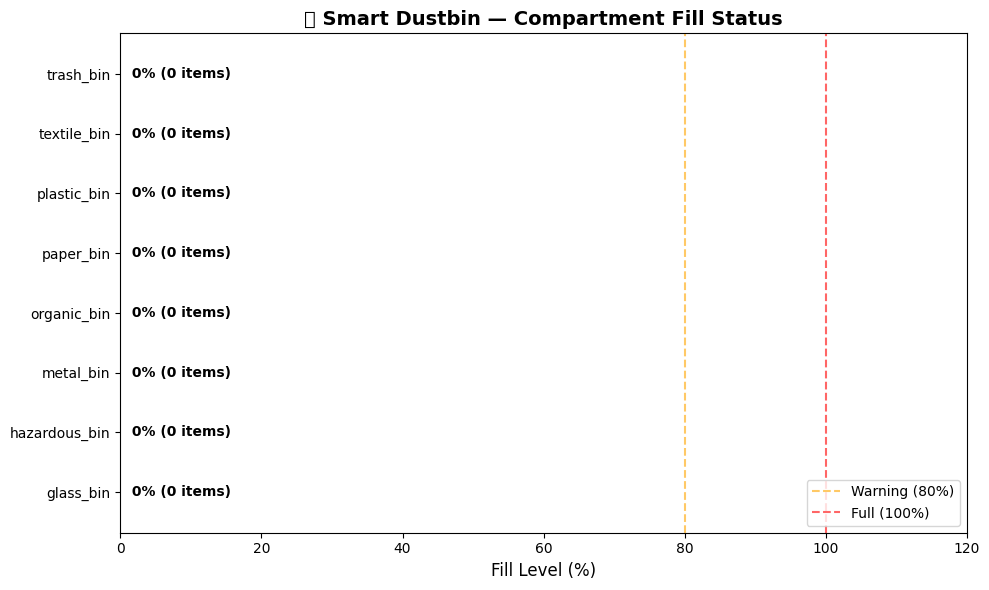

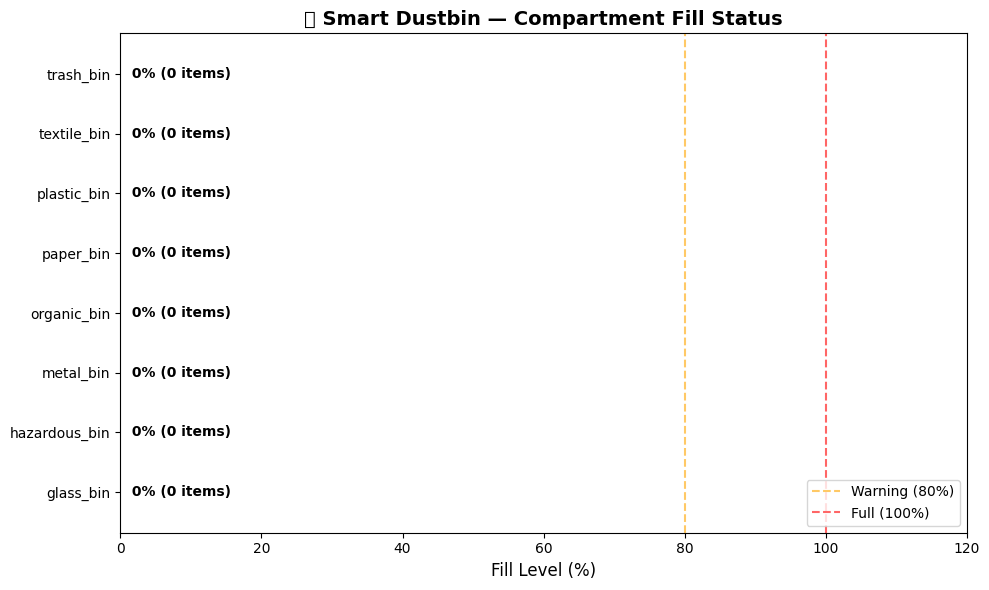

In [4]:
dustbin = SmartDustbin(bin_mapping=BIN_MAPPING)
print("\n🗑️ Virtual Smart Dustbin initialized!")
print(f"   Compartments: {list(dustbin.bins.keys())}")

# Show initial status
dustbin.display_bin_status(
    save_path=str(PATHS["outputs"] / "bin_status_initial.png")
)

## 3. Classification & Bin Mapping Demo
Let's classify some test images and see which bins they go to.

In [5]:
test_dir = PATHS["dataset"] / "test"
if not test_dir.exists():
    test_dir = PATHS["raw_data"]
    print(f"[INFO] Using raw dataset for demo: {test_dir}")

# Gather sample images from multiple classes
sample_images = []
for cls_dir in sorted(test_dir.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir() if f.is_file()]
        if imgs:
            # Pick up to 3 random images per class
            selected = random.sample(imgs, min(3, len(imgs)))
            sample_images.extend(selected)

random.shuffle(sample_images)
print(f"\n📷 Found {len(sample_images)} sample images for simulation.\n")


📷 Found 30 sample images for simulation.



## 4. Run Simulation
Process each image through the full pipeline:
image → classify → estimate size → assign bin → update fill → log

In [6]:
size_config = {
    "thresholds": AREA_THRESHOLDS,
    "contributions": FILL_CONTRIBUTION,
}

NUM_SIMULATE = min(30, len(sample_images))  # simulate 30 images
print(f"Simulating {NUM_SIMULATE} waste items...\n")
print(f"{'─'*80}")
print(f"{'#':>3} {'Image':>30s}  {'Predicted':>12s} {'Conf':>6s}  "
      f"{'Size':>10s} {'Fill%':>5s}  {'Bin':>15s} {'BinFill':>8s}")
print(f"{'─'*80}")

for i, img_path in enumerate(sample_images[:NUM_SIMULATE], 1):
    result = dustbin.process_image(
        model=model,
        image=str(img_path),
        device=device,
        class_names=CLASS_NAMES,
        image_size=224,
        size_config=size_config,
    )

    pred = result["prediction"]
    fill = result["fill_estimation"]
    event = result["bin_event"]

    print(f"{i:3d} {img_path.name:>30s}  {pred['class_name']:>12s} "
          f"{pred['confidence']:>5.1%}  {fill['size_category']:>10s} "
          f"{fill['fill_percent']:>4d}%  {event['target_bin']:>15s} "
          f"{event['bin_fill_after']:>7.1f}%")

print(f"{'─'*80}")

Simulating 30 waste items...

────────────────────────────────────────────────────────────────────────────────
  #                          Image     Predicted   Conf        Size Fill%              Bin  BinFill
────────────────────────────────────────────────────────────────────────────────
  1                 glass_1096.jpg         glass 67.8%       large   18%        glass_bin    18.0%
  2                plastic_668.jpg         metal 78.3%       large   18%        metal_bin    18.0%
  3                  metal_235.jpg         metal 94.3%      medium   10%        metal_bin    28.0%
  4               clothes_1248.jpg       clothes 88.5%      medium   10%      textile_bin    10.0%
  5                  metal_402.jpg         metal 95.1%      medium   10%        metal_bin    38.0%
  6                 paper_1028.jpg         paper 88.9%      medium   10%        paper_bin    10.0%
  7                  metal_415.jpg         metal 92.2%      medium   10%        metal_bin    48.0%
  8            

## 5. Updated Bin Status Dashboard


📊 Bin Status After Simulation:


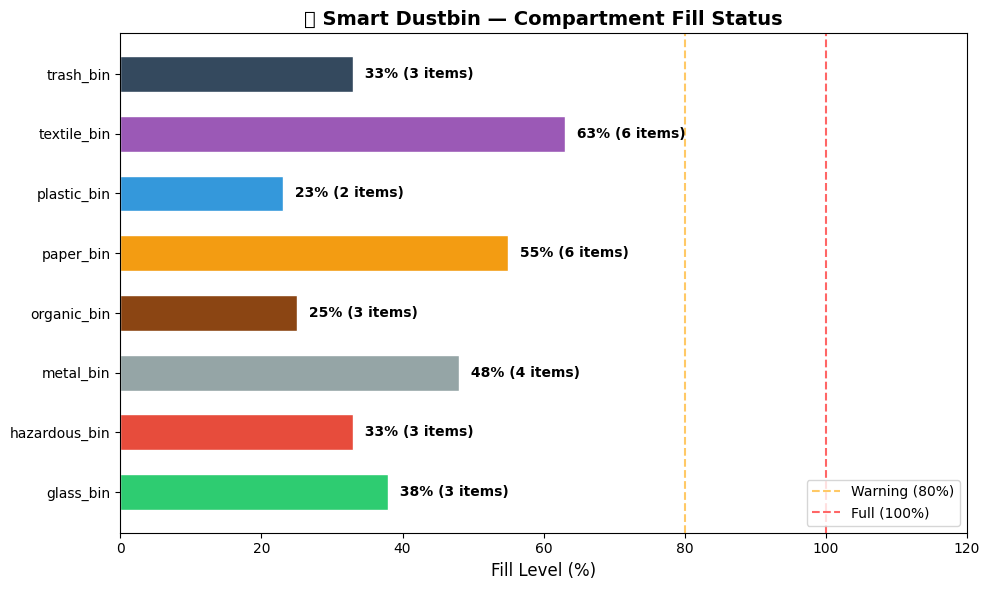


Compartment            Fill %    Items       Status
────────────────────────────────────────────────────
glass_bin               38.0%       3         ✅ OK
hazardous_bin           33.0%       3         ✅ OK
metal_bin               48.0%       4         ✅ OK
organic_bin             25.0%       3         ✅ OK
paper_bin               55.0%       6         ✅ OK
plastic_bin             23.0%       2         ✅ OK
textile_bin             63.0%       6         ✅ OK
trash_bin               33.0%       3         ✅ OK


In [7]:
print("\n📊 Bin Status After Simulation:")
dustbin.display_bin_status(
    save_path=str(PATHS["outputs"] / "bin_status_after_simulation.png")
)

# Print text summary
status = dustbin.get_status()
print(f"\n{'Compartment':<20s} {'Fill %':>8s} {'Items':>8s} {'Status':>12s}")
print("─" * 52)
for name, info in status.items():
    state = "🚨 FULL" if info["is_full"] else ("⚠️ HIGH" if info["is_near_full"] else "✅ OK")
    print(f"{name:<20s} {info['fill_percentage']:>7.1f}% {info['item_count']:>7d} {state:>12s}")

## 6. Detailed Prediction Visualisation

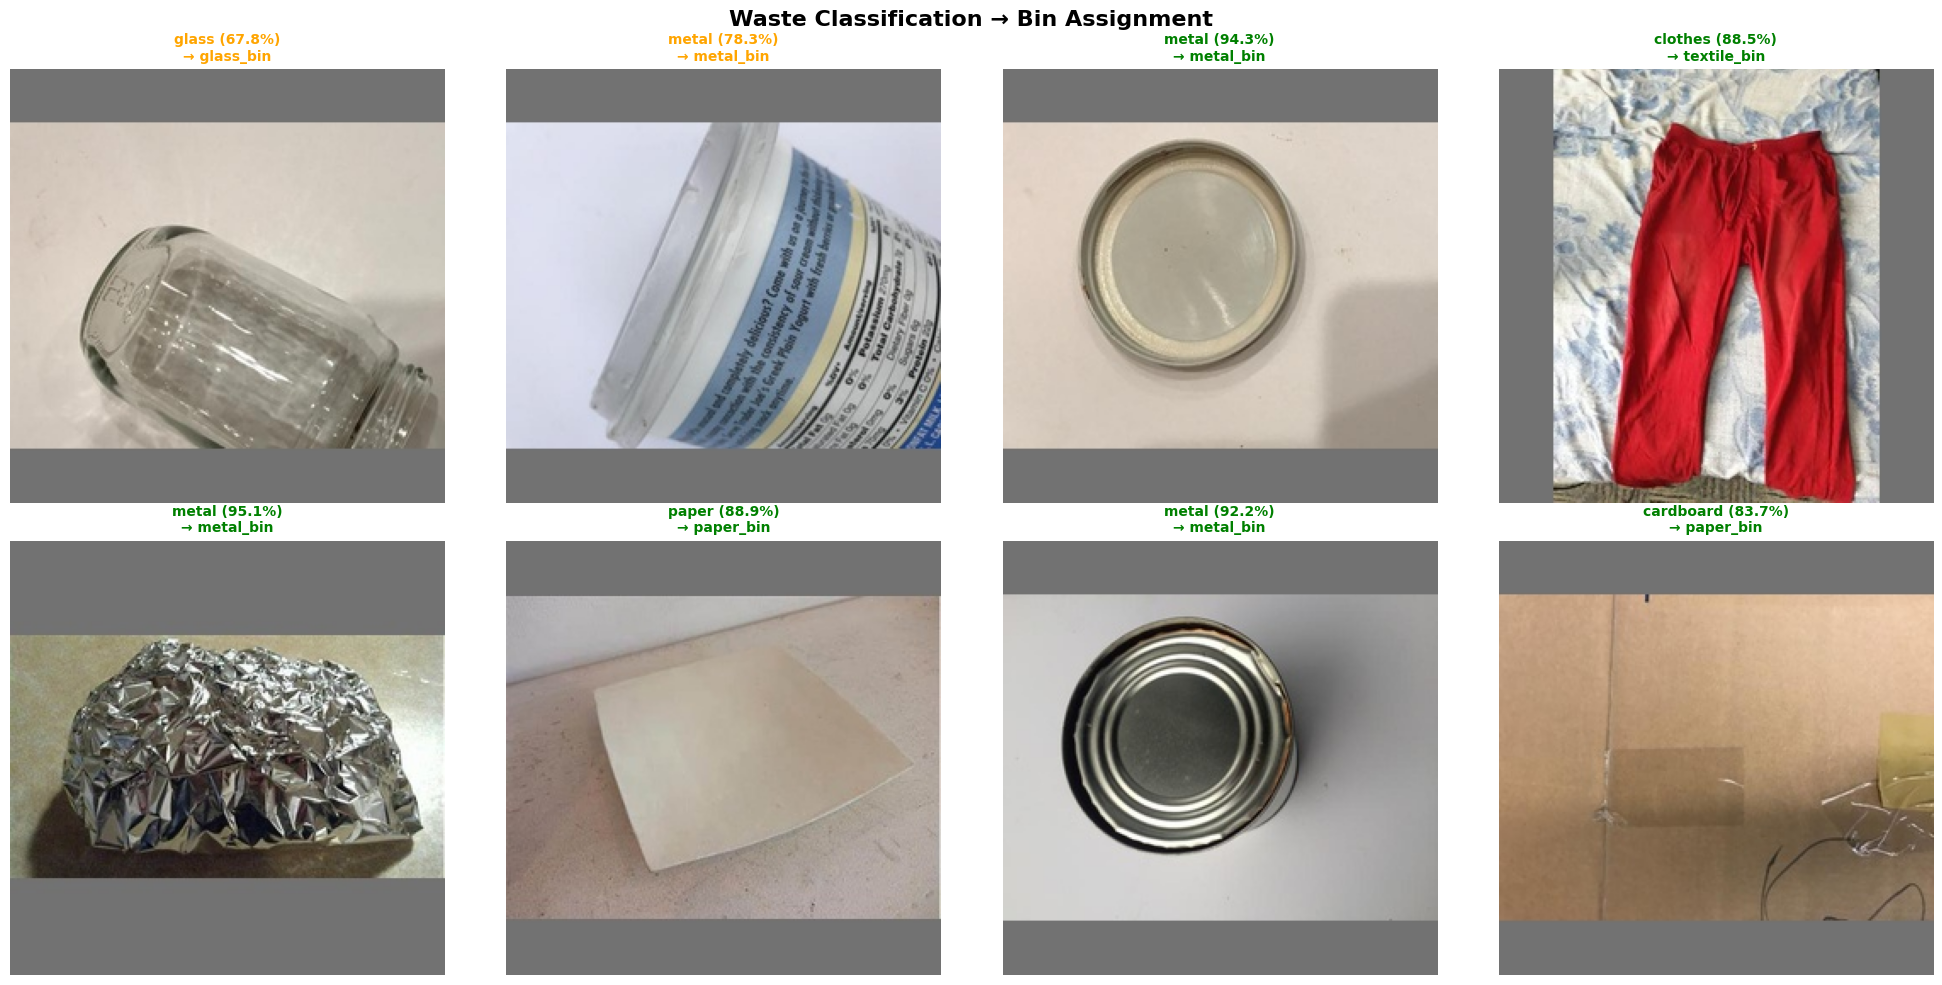

In [8]:
num_show = min(8, len(sample_images))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(num_show):
    img_path = sample_images[i]
    img = Image.open(img_path).convert("RGB")
    pred = predict_waste(model, img, device, CLASS_NAMES)

    axes[i].imshow(img)
    bin_name = map_class_to_bin(pred["class_name"])
    color = "green" if pred["confidence"] > 0.8 else ("orange" if pred["confidence"] > 0.5 else "red")
    axes[i].set_title(
        f"{pred['class_name']} ({pred['confidence']:.1%})\n→ {bin_name}",
        fontsize=10, fontweight="bold", color=color)
    axes[i].axis("off")

for i in range(num_show, len(axes)):
    axes[i].axis("off")

fig.suptitle("Waste Classification → Bin Assignment", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(str(PATHS["outputs"] / "prediction_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Event Log & Analytics

In [9]:
dustbin.save_log(str(PATHS["logs"] / "simulation_event_log.json"))

[INFO] Event log saved → c:\SDIS\logs\simulation_event_log.json (30 events)


In [10]:
df_log = dustbin.get_log_dataframe()
if not df_log.empty:
    print("\n📈 Event Log Summary:")
    print(f"   Total events: {len(df_log)}")
    print(f"\n   Waste class distribution:")
    print(df_log["waste_class"].value_counts().to_string())
    print(f"\n   Average confidence: {df_log['confidence'].mean():.2%}")
    print(f"\n   Bins used:")
    print(df_log["target_bin"].value_counts().to_string())

    # Save analytics
    df_log.to_csv(PATHS["logs"] / "simulation_analytics.csv", index=False)


📈 Event Log Summary:
   Total events: 30

   Waste class distribution:
waste_class
metal         4
cardboard     4
glass         3
clothes       3
shoes         3
trash         3
biological    3
battery       3
paper         2
plastic       2

   Average confidence: 83.97%

   Bins used:
target_bin
paper_bin        6
textile_bin      6
metal_bin        4
glass_bin        3
trash_bin        3
hazardous_bin    3
organic_bin      3
plastic_bin      2


## 8. Webcam Mode (Optional)
Uncomment the cell below to run live webcam classification.
Press 'q' to quit.

In [11]:
# import cv2
#
# cap = cv2.VideoCapture(0)
# if not cap.isOpened():
#     print("Cannot open webcam")
# else:
#     print("Press 'q' to quit webcam mode.")
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break
#
#         # Convert BGR to RGB for prediction
#         frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         pil_img = Image.fromarray(frame_rgb)
#
#         pred = predict_waste(model, pil_img, device, CLASS_NAMES)
#         fill = estimate_fill_contribution(pil_img, size_config)
#         bin_name = map_class_to_bin(pred["class_name"])
#
#         # Draw info on frame
#         label = f"{pred['class_name']} ({pred['confidence']:.1%}) -> {bin_name}"
#         cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
#                     0.8, (0, 255, 0), 2)
#         cv2.putText(frame, f"Size: {fill['size_category']}",
#                     (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 1)
#
#         cv2.imshow("Smart Dustbin — Waste Classifier", frame)
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break
#
#     cap.release()
#     cv2.destroyAllWindows()

## ✅ Simulation Complete

**Important Notes:**
- Fill estimation is **approximate** (image‑area heuristic).
- Real deployment would need depth sensors, real bin dimensions,
  and camera calibration.
- This prototype demonstrates the full pipeline: classify → segregate
  → estimate → log → alert.

For an interactive UI demo, run: `streamlit run streamlit_app.py`

print("\n" + "=" * 60)
print("  SMART DUSTBIN SIMULATION COMPLETE")
print("=" * 60)